<a href="https://colab.research.google.com/github/Lucas-d-Silva/Projeto_steam_games/blob/main/Projeto_fase2_Programa%C3%A7%C3%A3o_para_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Curso superior de Tecnologia em Banco de dados**

**Autor:** Lucas da Silva


**Link do Github:** https://github.com/Lucas-d-Silva/Projeto_steam_games/tree/main/Fase_2


**Disciplina:** Programção para dados




**Finalidade:** Criar um programa para analisar e responder as perguntas sobre os dados do dataset: Steam_games.csv



**Data:** Setembro de 2026



In [11]:


# CÉLULA 1: Importação de Bibliotecas e Estilo Visual Customizado

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import IPython
from IPython.display import display, HTML, Markdown

# Configuração do Estilo Customizado para Padronização de Figuras

def aplicar_estilo_customizado():
    """
    Define parâmetros globais do matplotlib para garantir coesão visual,
    legibilidade e padrão profissional em todas as figuras geradas.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.size'] = 11

    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.titlepad'] = 14
    plt.rcParams['axes.labelsize'] = 11
    plt.rcParams['axes.labelweight'] = 'bold'

    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['axes.edgecolor'] = '#B0BEC5'
    plt.rcParams['axes.linewidth'] = 0.8
    plt.rcParams['grid.color'] = '#E0E0E0'
    plt.rcParams['grid.linestyle'] = '--'
    plt.rcParams['grid.alpha'] = 0.7

    plt.rcParams['figure.figsize'] = (10, 5)
    plt.rcParams['figure.dpi'] = 120

aplicar_estilo_customizado()

PALETA_FUNCORP = {
    'azul_principal': '#1F4E78',
    'verde_suporte': '#2E7D32',
    'laranja_destaque': '#D95F02',
    'roxo_neutro': '#7570B3',
    'rosa_acento': '#E7298A'
}

display(Markdown("### ✅ [CÉLULA 1 EXECUTADA]"))
display(Markdown("Bibliotecas carregadas (`pandas`, `numpy`, `matplotlib`, `IPython/Jupyter`) e estilo gráfico padronizado com sucesso."))

### ✅ [CÉLULA 1 EXECUTADA]

Bibliotecas carregadas (`pandas`, `numpy`, `matplotlib`, `IPython/Jupyter`) e estilo gráfico padronizado com sucesso.

In [9]:
from google.colab import files

# ------------------------------------------------------------------------------
# 1. Carregamento do Arquivo CSV da Steam
# ------------------------------------------------------------------------------
display(Markdown("#### 📥 Faça o upload do arquivo `games.csv` da Steam:"))
uploaded = files.upload()

nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(nome_arquivo)

display(Markdown(f"**Dataset carregado com sucesso!** Total de registros: `{df.shape[0]}` linhas e `{df.shape[1]}` colunas."))

# ------------------------------------------------------------------------------
# 2. Pré-Processamento dos Dados
# ------------------------------------------------------------------------------

# A. Conversão de Datas de Lançamento e Extração do Ano
df['Release date'] = pd.to_datetime(df['Release date'], errors='coerce')
df['Release_Year'] = df['Release date'].dt.year

# B. Tratamento de Colunas Numéricas
cols_numericas = ['Price', 'Metacritic score', 'Positive', 'Negative', 'DLC count', 'Average playtime forever']
for col in cols_numericas:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# C. Conversão de Colunas Booleanas
for col in ['Windows', 'Mac', 'Linux']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.lower().map({
            'true': True, '1': True, '1.0': True,
            'false': False, '0': False, '0.0': False
        }).fillna(False)

# D. Criação da Coluna 'Demo_materials'
def extrair_quantidade_midias(coluna_midia):
    if pd.isna(coluna_midia) or coluna_midia == '' or coluna_midia == '[]':
        return 0
    if isinstance(coluna_midia, str):
        return len([item for item in coluna_midia.split(',') if item.strip()])
    return 0

df['Screenshots_count'] = df['Screenshots'].apply(extrair_quantidade_midias)
df['Movies_count'] = df['Movies'].apply(extrair_quantidade_midias)
df['Demo_materials'] = df['Screenshots_count'] + df['Movies_count']

# ------------------------------------------------------------------------------
# 3. Confirmação
# ------------------------------------------------------------------------------
display(Markdown("### ✅ [CÉLULA 2 EXECUTADA COM SUCESSO]"))
display(Markdown(f"""
**Resumo do Pré-processamento:**
* **Período de Lançamentos Identificado:** `{int(df['Release_Year'].min())}` a `{int(df['Release_Year'].max())}`.
* **Média de Materiais Demonstrativos (`Demo_materials`):** `{df['Demo_materials'].mean():.2f}` mídias por jogo.
* **Tipos Sanitizados:** Datas (`Release date`), Numéricos (`Price`, `Metacritic score`, etc.) e Booleanos (`Windows`, `Mac`, `Linux`).
"""))

#### 📥 Faça o upload do arquivo `games.csv` da Steam:

Saving steam_games.csv to steam_games.csv


**Dataset carregado com sucesso!** Total de registros: `72934` linhas e `39` colunas.

### ✅ [CÉLULA 2 EXECUTADA COM SUCESSO]


**Resumo do Pré-processamento:**
* **Período de Lançamentos Identificado:** `1997` a `2025`.
* **Média de Materiais Demonstrativos (`Demo_materials`):** `10.01` mídias por jogo.
* **Tipos Sanitizados:** Datas (`Release date`), Numéricos (`Price`, `Metacritic score`, etc.) e Booleanos (`Windows`, `Mac`, `Linux`).


In [21]:
# ==============================================================================
# FASE II - CÉLULA 3: Resolução das Perguntas de Negócio 1 a 4
# ==============================================================================

# ------------------------------------------------------------------------------
# PERGUNTA 1:
# Dez jogos mais bem avaliados no Metacritic (Desempate: Data de lançamento mais antiga)
# ------------------------------------------------------------------------------
df_p1 = df[df['Metacritic score'] > 0].copy()

# Remove duplicatas mantendo apenas a primeira ocorrência do jogo
df_p1_limpo = df_p1.drop_duplicates(subset=['Name'], keep='first')

p1_top10 = df_p1_limpo.sort_values(
    by=['Metacritic score', 'Release date'],
    ascending=[False, True]
).head(10)[['Name', 'Metacritic score', 'Release date']].reset_index(drop=True)

p1_top10['Release date'] = p1_top10['Release date'].dt.strftime('%d/%m/%Y')

display(Markdown("### 📌 Pergunta 1: Top 10 Jogos no Metacritic"))
display(p1_top10)


# ------------------------------------------------------------------------------
# PERGUNTA 2:
# RPG: Média e Máximo de DLCs, Avaliações (+/-) e Demo_materials
# ------------------------------------------------------------------------------
jogos_rpg = df[df['Genres'].astype(str).str.contains('RPG|Role-Playing', case=False, na=False)]

p2_resultado = pd.DataFrame({
    'Métrica': ['DLCs', 'Avaliações Positivas', 'Avaliações Negativas', 'Materiais de Demonstração (Demo_materials)'],
    'Média': [
        jogos_rpg['DLC count'].mean(),
        jogos_rpg['Positive'].mean(),
        jogos_rpg['Negative'].mean(),
        jogos_rpg['Demo_materials'].mean()
    ],
    'Máximo': [
        jogos_rpg['DLC count'].max(),
        jogos_rpg['Positive'].max(),
        jogos_rpg['Negative'].max(),
        jogos_rpg['Demo_materials'].max()
    ]
})

p2_resultado['Média'] = p2_resultado['Média'].round(2)
p2_resultado['Máximo'] = p2_resultado['Máximo'].astype(int)

display(Markdown("### 📌 Pergunta 2: Estatísticas para Jogos de RPG"))
display(p2_resultado)


# ------------------------------------------------------------------------------
# PERGUNTA 3:
# Top 5 Publishers de Jogos Pagos (e média/mediana de avaliações positivas)
# ------------------------------------------------------------------------------
df_pagos = df[df['Price'] > 0].copy()

# Tratamento para publishers (remover nulos/vazios)
df_pagos_pub = df_pagos[df_pagos['Publishers'].notna() & (df_pagos['Publishers'] != '')]

top5_publishers = df_pagos_pub['Publishers'].value_counts().head(5).index.tolist()

df_top5_pub = df_pagos_pub[df_pagos_pub['Publishers'].isin(top5_publishers)]

p3_resultado = df_top5_pub.groupby('Publishers')['Positive'].agg(
    Qtd_Jogos_Pagos='count',
    Media_Avaliacoes_Positivas='mean',
    Mediana_Avaliacoes_Positivas='median'
).loc[top5_publishers].reset_index()

p3_resultado['Media_Avaliacoes_Positivas'] = p3_resultado['Media_Avaliacoes_Positivas'].round(2)

display(Markdown("### 📌 Pergunta 3: Top 5 Publishers de Jogos Pagos"))
display(p3_resultado)


# ------------------------------------------------------------------------------
# PERGUNTA 4:
# Crescimento do suporte ao Linux entre 2018 e 2022
# ------------------------------------------------------------------------------
df_p4 = df[(df['Release_Year'] >= 2018) & (df['Release_Year'] <= 2022)]
p4_totais = df_p4.groupby('Release_Year')['Linux'].sum().reset_index()

qtd_2018 = p4_totais.loc[p4_totais['Release_Year'] == 2018, 'Linux'].values[0]
qtd_2022 = p4_totais.loc[p4_totais['Release_Year'] == 2022, 'Linux'].values[0]
crescimento_pct = ((qtd_2022 - qtd_2018) / qtd_2018) * 100

display(Markdown("### 📌 Pergunta 4: Evolução do Suporte ao Linux (2018 vs 2022)"))
display(p4_totais)
display(Markdown(f"**Análise:** Em 2018 havia **{qtd_2018:,}** jogos com suporte ao Linux, enquanto em 2022 esse número passou para **{qtd_2022:,}**, representando uma variação de **{crescimento_pct:.2f}%** no período."))

display(Markdown("### ✅ [CÉLULA 3 EXECUTADA COM SUCESSO]"))

### 📌 Pergunta 1: Top 10 Jogos no Metacritic

,Name,Metacritic score,Release date
0,Disco Elysium - The Final Cut,97,15/10/2019
1,Persona 5 Royal,97,20/10/2022
2,Half-Life,96,08/11/1998
3,Half-Life 2,96,16/11/2004
4,BioShock™,96,21/08/2007
5,Grand Theft Auto V,96,13/04/2015
6,Portal 2,95,18/04/2011
7,Sid Meier's Civilization® IV,94,25/10/2006
8,QUAKE,94,03/08/2007
9,The Elder Scrolls IV: Oblivion® Game of the Ye...,94,16/06/2009


### 📌 Pergunta 2: Estatísticas para Jogos de RPG

,Métrica,Média,Máximo
0,DLCs,0.95,2366
1,Avaliações Positivas,1516.41,964983
2,Avaliações Negativas,247.17,129925
3,Materiais de Demonstração (Demo_materials),11.32,187


### 📌 Pergunta 3: Top 5 Publishers de Jogos Pagos

,Publishers,Qtd_Jogos_Pagos,Media_Avaliacoes_Positivas,Mediana_Avaliacoes_Positivas
0,Big Fish Games,443,7.36,5.0
1,8floor,239,4.46,3.0
2,Strategy First,162,276.45,23.0
3,Laush Studio,157,19.78,12.0
4,HH-Games,156,10.54,9.0


### 📌 Pergunta 4: Evolução do Suporte ao Linux (2018 vs 2022)

,Release_Year,Linux
0,2018.0,1187
1,2019.0,922
2,2020.0,1082
3,2021.0,1210
4,2022.0,1311


**Análise:** Em 2018 havia **1,187** jogos com suporte ao Linux, enquanto em 2022 esse número passou para **1,311**, representando uma variação de **10.45%** no período.

### ✅ [CÉLULA 3 EXECUTADA COM SUCESSO]

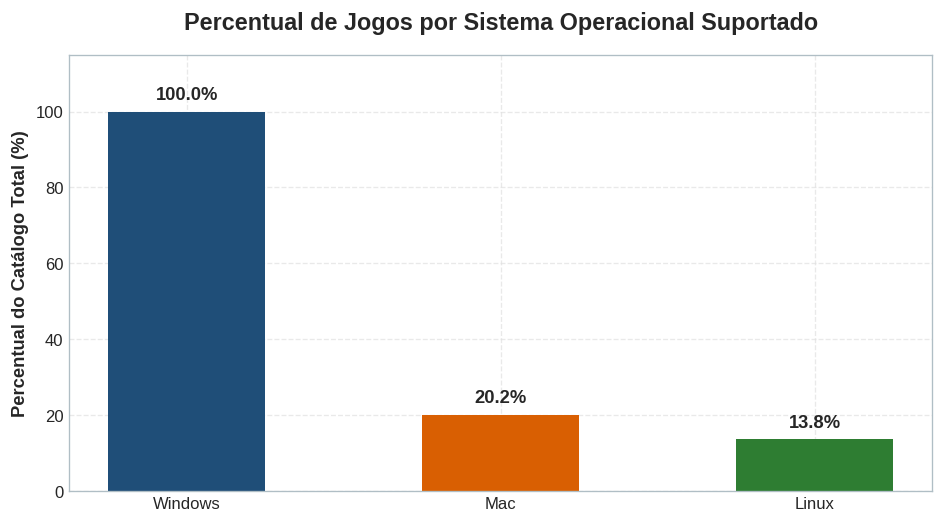

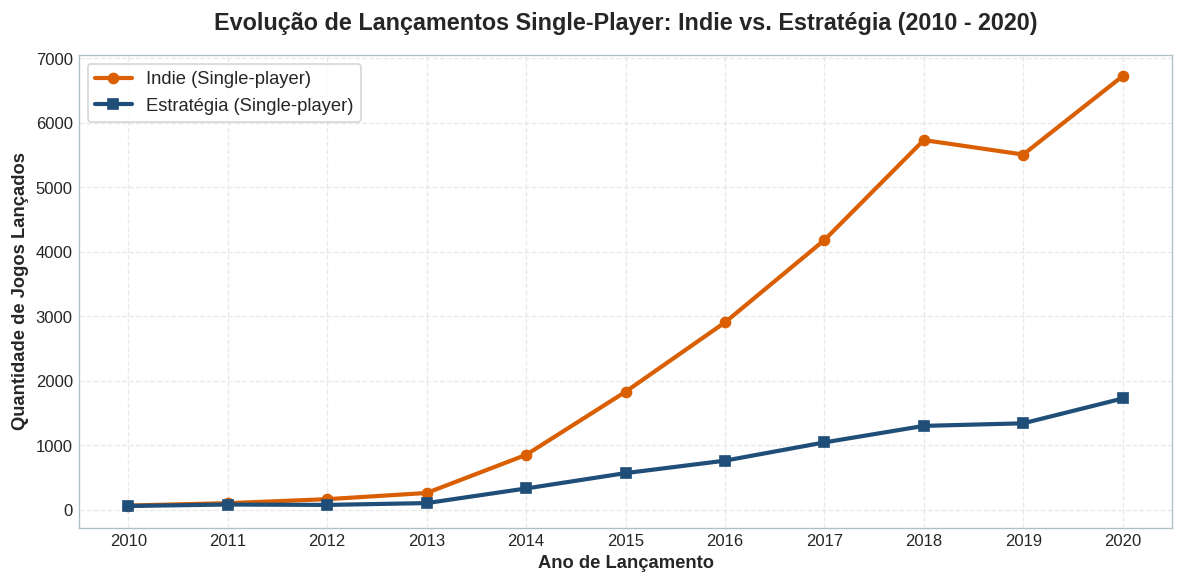

### ✅ [CÉLULA 4 EXECUTADA COM SUCESSO]

In [17]:
# ==============================================================================
# FASE II - CÉLULA 4: Visualizações Gráficas Obrigatórias (Gráficos 1 e 2)
# ==============================================================================

# ------------------------------------------------------------------------------
# GRÁFICO 1: Percentual de jogos com suporte a cada SO (Voto por SO)
# ------------------------------------------------------------------------------
total_jogos = len(df)
so_counts = {
    'Windows': df['Windows'].sum(),
    'Mac': df['Mac'].sum(),
    'Linux': df['Linux'].sum()
}

df_g1 = pd.DataFrame({
    'Sistema Operacional': list(so_counts.keys()),
    'Quantidade': list(so_counts.values())
})
df_g1['Percentual'] = (df_g1['Quantidade'] / total_jogos) * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(df_g1['Sistema Operacional'], df_g1['Percentual'], color=[PALETA_FUNCORP['azul_principal'], PALETA_FUNCORP['laranja_destaque'], PALETA_FUNCORP['verde_suporte']], width=0.5)

ax.set_title('Percentual de Jogos por Sistema Operacional Suportado', pad=15)
ax.set_ylabel('Percentual do Catálogo Total (%)')
ax.set_ylim(0, 115)

# Adiciona rótulos percentuais sobre as barras
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


# ------------------------------------------------------------------------------
# GRÁFICO 2: Tendência Single-Player Indie vs. Estratégia (2010 a 2020)
# ------------------------------------------------------------------------------
# Filtro: Anos 2010-2020 + Categoria Single-player
df_sp = df[(df['Release_Year'] >= 2010) & (df['Release_Year'] <= 2020)].copy()

# Verifica suporte a Single-player na coluna Categories ou similar
df_sp_filtered = df_sp[df_sp['Categories'].astype(str).str.contains('Single-player', case=False, na=False)]

# Contagem por ano para Indie
indie_sp = df_sp_filtered[df_sp_filtered['Genres'].astype(str).str.contains('Indie', case=False, na=False)].groupby('Release_Year').size()

# Contagem por ano para Strategy
strat_sp = df_sp_filtered[df_sp_filtered['Genres'].astype(str).str.contains('Strategy', case=False, na=False)].groupby('Release_Year').size()

df_g2 = pd.DataFrame({'Indie': indie_sp, 'Estratégia': strat_sp}).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_g2.index, df_g2['Indie'], label='Indie (Single-player)', color=PALETA_FUNCORP['laranja_destaque'], marker='o', linewidth=2.5)
ax.plot(df_g2.index, df_g2['Estratégia'], label='Estratégia (Single-player)', color=PALETA_FUNCORP['azul_principal'], marker='s', linewidth=2.5)

ax.set_title('Evolução de Lançamentos Single-Player: Indie vs. Estratégia (2010 - 2020)', pad=15)
ax.set_xlabel('Ano de Lançamento')
ax.set_ylabel('Quantidade de Jogos Lançados')
ax.set_xticks(range(2010, 2021))
ax.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

display(Markdown("### ✅ [CÉLULA 4 EXECUTADA COM SUCESSO]"))

### 📌 Pergunta Autoral: Impacto da Localização de Idiomas nos Jogos

,Categoria_Idiomas,Qtd_Jogos,Preco_Medio,Playtime_Medio_Horas
0,Idioma Único (1),43179,5.73,0.85
1,Multi-idioma (>1),29753,9.40,3.55


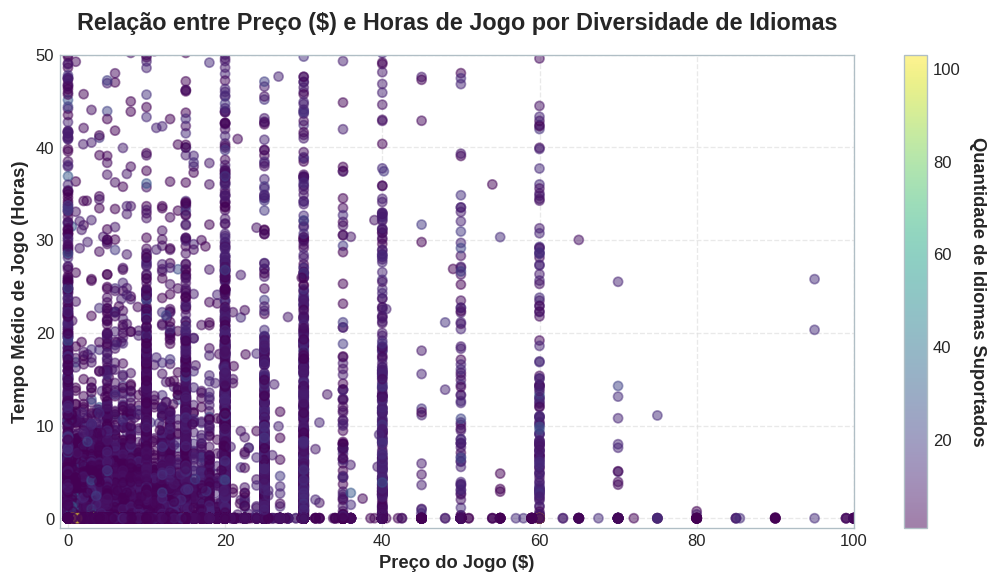

### ✅ [PROJETO COMPLETO E PRONTO PARA O RELATÓRIO PDF]

In [20]:
# ==============================================================================
# FASE II - CÉLULA 5: Pergunta de Negócio Autoral e Gráfico Adicional
# ==============================================================================

# ------------------------------------------------------------------------------
# PERGUNTA ADICIONAL (AUTORAL):
# Existe diferença significativa no preço médio e na retenção de jogadores (Playtime)
# entre jogos que oferecem suporte a múltiplos idiomas e aqueles com idioma único?
# ------------------------------------------------------------------------------

# Identifica contagem de idiomas suportados
def contar_idiomas(texto):
    if pd.isna(texto) or texto == '': return 1
    return len(str(texto).split(','))

df['Qtd_Idiomas'] = df['Supported languages'].apply(contar_idiomas)
df['Categoria_Idiomas'] = np.where(df['Qtd_Idiomas'] > 1, 'Multi-idioma (>1)', 'Idioma Único (1)')

p5_resultado = df.groupby('Categoria_Idiomas').agg(
    Qtd_Jogos=('Name', 'count'),
    Preco_Medio=('Price', 'mean'),
    Playtime_Medio_Horas=('Average playtime forever', lambda x: (x.mean() / 60))
).reset_index()

p5_resultado['Preco_Medio'] = p5_resultado['Preco_Medio'].round(2)
p5_resultado['Playtime_Medio_Horas'] = p5_resultado['Playtime_Medio_Horas'].round(2)

display(Markdown("### 📌 Pergunta Autoral: Impacto da Localização de Idiomas nos Jogos"))
display(p5_resultado)

# ------------------------------------------------------------------------------
# GRÁFICO ADICIONAL (AUTORAL):
# Relação entre Preço e Avaliações Positivas por Categoria de Idioma (Boxplot/Scatter)
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5))

# Dispersão Preço vs. Playtime
scatter = ax.scatter(
    df['Price'],
    df['Average playtime forever'] / 60,
    c=df['Qtd_Idiomas'],
    cmap='viridis',
    alpha=0.5,
    s=30
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Quantidade de Idiomas Suportados', rotation=270, labelpad=15)

ax.set_title('Relação entre Preço ($) e Horas de Jogo por Diversidade de Idiomas', pad=15)
ax.set_xlabel('Preço do Jogo ($)')
ax.set_ylabel('Tempo Médio de Jogo (Horas)')
ax.set_xlim(-1, 100) # Limita eixo x para evitar outliers de preços extremos
ax.set_ylim(-1, 50)  # Limita eixo y para visualização clara do grosso dos dados

plt.tight_layout()
plt.show()

display(Markdown("### ✅ [PROJETO COMPLETO E PRONTO PARA O RELATÓRIO PDF]"))